In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
from math import sqrt


In [8]:

# Load your dataset (update with the correct path)
df = pd.read_csv("HINDUNILVR.NS.csv")

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Select the 'Adj Close' column as the target
target_col = 'Adj Close'
df_train = df.copy()

# Impute missing values IN NUMERICAL COLUMNS
imputer = SimpleImputer(strategy='mean')  
df_train_numerical = df_train.drop('Date', axis=1)  # Exclude Date
df_train_numerical = pd.DataFrame(imputer.fit_transform(df_train_numerical), columns=df_train_numerical.columns) 

# Add the 'Date' column back 
df_train = df_train_numerical.copy()
df_train['Date'] = df['Date'].copy() 

# Create features and target variable 
X = df_train.drop(['Adj Close', 'Date'], axis=1) 
y = df_train[target_col]

# Normalize the data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = y.values.reshape(-1, 1)  # Reshape for LSTM input
y = scaler.fit_transform(y)

# Define lookback window for time-series
lookback = 60 

# Create dataset with a 60-day lookback window
X_new = []
y_new = []
for i in range(lookback, len(X)):
    X_new.append(X[i-lookback:i])
    y_new.append(y[i])

X_new, y_new = np.array(X_new), np.array(y_new)

# Train-test split (e.g., 80%/20%)
split_index = int(len(X_new) * 0.8)
X_train, X_test = X_new[:split_index], X_new[split_index:]
y_train, y_test = y_new[:split_index], y_new[split_index:]

# Define the LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model 
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)

# Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Calculate MSE and RMSE 
mse = mean_squared_error(y_test, predictions)
rmse = sqrt(mse)  

# Print the MSE and RMSE scores
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)


Epoch 1/50
123/123 - 6s - loss: 0.0027 - 6s/epoch - 49ms/step
Epoch 2/50
123/123 - 4s - loss: 1.6606e-04 - 4s/epoch - 32ms/step
Epoch 3/50
123/123 - 4s - loss: 1.6426e-04 - 4s/epoch - 32ms/step
Epoch 4/50
123/123 - 4s - loss: 1.6738e-04 - 4s/epoch - 32ms/step
Epoch 5/50
123/123 - 4s - loss: 1.7701e-04 - 4s/epoch - 32ms/step
Epoch 6/50
123/123 - 4s - loss: 1.6252e-04 - 4s/epoch - 32ms/step
Epoch 7/50
123/123 - 4s - loss: 1.7340e-04 - 4s/epoch - 32ms/step
Epoch 8/50
123/123 - 4s - loss: 1.5806e-04 - 4s/epoch - 32ms/step
Epoch 9/50
123/123 - 4s - loss: 1.6460e-04 - 4s/epoch - 32ms/step
Epoch 10/50
123/123 - 4s - loss: 1.5512e-04 - 4s/epoch - 32ms/step
Epoch 11/50
123/123 - 4s - loss: 1.5310e-04 - 4s/epoch - 32ms/step
Epoch 12/50
123/123 - 4s - loss: 1.4237e-04 - 4s/epoch - 32ms/step
Epoch 13/50
123/123 - 4s - loss: 1.6472e-04 - 4s/epoch - 32ms/step
Epoch 14/50
123/123 - 4s - loss: 1.7541e-04 - 4s/epoch - 32ms/step
Epoch 15/50
123/123 - 4s - loss: 1.3415e-04 - 4s/epoch - 32ms/step
Epoch 16

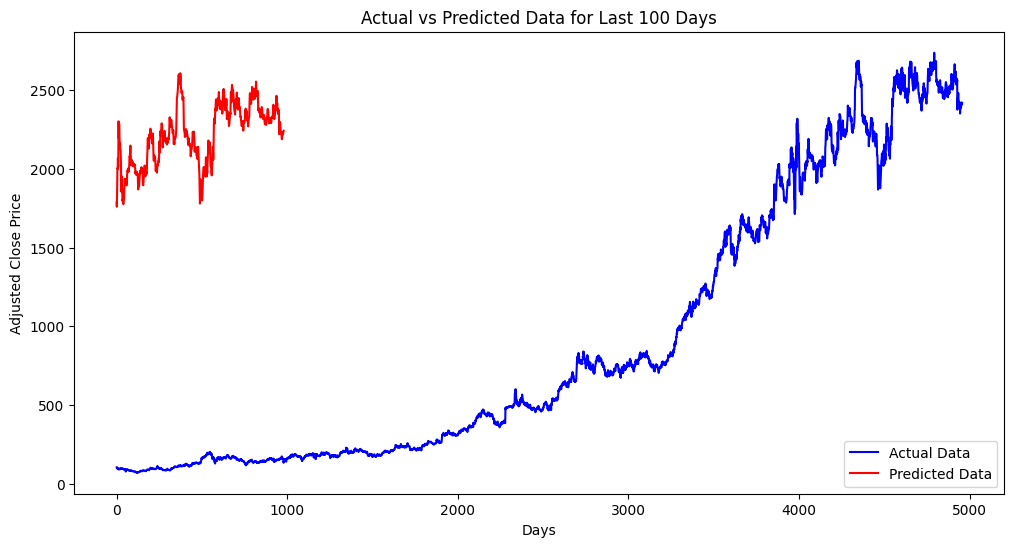

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Get the last 100 days data
actual_data = df['Adj Close'].values
predicted_data = predictions.flatten()

# Plot actual vs predicted data
plt.figure(figsize=(12, 6))
plt.plot(actual_data, label='Actual Data', color='blue')
plt.plot(predicted_data, label='Predicted Data', color='red')
plt.title('Actual vs Predicted Data for Last 100 Days')
plt.xlabel('Days')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()
